# Basis sets for 2D materials: improving vacuum description

### Exercise 2.1: Change the Energy Shift 300 meV, 100 meV, 50 meV and 10 meV.Check the BasisEnthalpy and the TotalEnergy of the system

In [1]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene


In [2]:
ls

C_ghost.psml  graphene.diffuse.fdf  graphene.ghosts.fdf
C.psml        graphene.fdf          Untitled.ipynb


In [28]:
!mkdir Ex_2    # contain exercise 2.1 and 2.2

mkdir: cannot create directory ‘Ex_2’: File exists


In [4]:
!cp C_ghost.psml  graphene.diffuse.fdf  graphene.ghosts.fdf C.psml  graphene.fdf Ex_2/  

In [5]:
%cd Ex_2

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
ls

C_ghost.psml  C.psml  graphene.diffuse.fdf  graphene.fdf  graphene.ghosts.fdf


In [7]:
energy_shift = [10,50, 100, 300]

for Z in energy_shift:
    subf = f"ES_{Z}"

    # create folder
    !mkdir -p {subf}

    # copy input files
    !cp C_ghost.psml  graphene.diffuse.fdf  graphene.ghosts.fdf C.psml  graphene.fdf {subf}/

    # modify EnergyShift
    !sed -i "s/PAO.EnergyShift.*/PAO.EnergyShift {Z} meV/" {subf}/graphene.fdf

    # run siesta
    !cd {subf} && siesta graphene.fdf > graphene.out


Job completed
Job completed
Job completed
Job completed


In [8]:
for Z in energy_shift:
    print(f"ES_{Z}", end=" ")
    !grep "E + p_basis" ES_{Z}/graphene.out

ES_10     (Free)E + p_basis*V_orbitals       =        -324.173220 eV
ES_50     (Free)E + p_basis*V_orbitals       =        -324.985662 eV
ES_100     (Free)E + p_basis*V_orbitals       =        -325.241538 eV
ES_300     (Free)E + p_basis*V_orbitals       =        -325.413043 eV


In [13]:
energy_shift = [10, 50, 100, 300]

print(f"{'Eshift(meV)':<12} {'BasisEnthalpy(eV)':<20} {'TotalEnergy(eV)'}")

for Z in energy_shift:
    out = f"ES_{Z}/graphene.out"

    basis_line = !grep -i "E + p_basis" $out
    total_line = !grep "Total =" $out

    basis_val = basis_line[0].split()[-2]
    total_val = total_line[0].split()[-1]

    print(f"{Z:<12} {basis_val:<20} {total_val}")


Eshift(meV)  BasisEnthalpy(eV)    TotalEnergy(eV)
10           -324.173220          -326.027291
50           -324.985662          -326.102046
100          -325.241538          -326.111045
300          -325.413043          -325.965841


### Exercise 2.2: Plot the band structure of graphene with 100 meV Energy Shift

In [15]:
!siesta < graphene.fdf > graphene.out


Job completed


In [16]:
ls

0_NORMAL_EXIT          fdf.20260110T115146.994.log  graphene.ghosts.fdf
BASIS_ENTHALPY         FORCE_STRESS                 graphene.HSX
BASIS_HARRIS_ENTHALPY  graphene.alloc               graphene.KP
C_ghost.psml           graphene.bands               graphene.ORB_INDX
C.ion                  graphene.BASIS_ENTHALPY      graphene.out
C.ion.nc               graphene.bib                 graphene.STRUCT_OUT
C.ion.xml              graphene.BONDS               graphene.XV
CLOCK                  graphene.BONDS_FINAL         INPUT_TMP.57864
C.psml                 graphene.diffuse.fdf         MESSAGES
ES_10/                 graphene.DM                  NON_TRIMMED_KP_LIST
ES_100/                graphene.EIG                 OUTVARS.yml
ES_300/                graphene.FA                  PARALLEL_DIST
ES_50/                 graphene.fdf


In [17]:
ls graphene.DM

graphene.DM


In [18]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2


In [19]:
ls

0_NORMAL_EXIT          fdf.20260110T115146.994.log  graphene.ghosts.fdf
BASIS_ENTHALPY         FORCE_STRESS                 graphene.HSX
BASIS_HARRIS_ENTHALPY  graphene.alloc               graphene.KP
C_ghost.psml           graphene.bands               graphene.ORB_INDX
C.ion                  graphene.BASIS_ENTHALPY      graphene.out
C.ion.nc               graphene.bib                 graphene.STRUCT_OUT
C.ion.xml              graphene.BONDS               graphene.XV
CLOCK                  graphene.BONDS_FINAL         INPUT_TMP.57864
C.psml                 graphene.diffuse.fdf         MESSAGES
ES_10/                 graphene.DM                  NON_TRIMMED_KP_LIST
ES_100/                graphene.EIG                 OUTVARS.yml
ES_300/                graphene.FA                  PARALLEL_DIST
ES_50/                 graphene.fdf


In [21]:
!gnubands -G -F -o graph -E 10 -e -20 graphene.bands


In [22]:
ls graph.*


graph.gplot


In [24]:
!gnuplot --persist graph.gplot


### Exercise 2.3: Do the same but with graphene.diffuse.fdf

In [25]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene


In [27]:
!mkdir Ex_2.1 # contain exercise 2.3 and 2.4

mkdir: cannot create directory ‘Ex_2.1’: File exists


In [29]:
!cp C_ghost.psml  graphene.diffuse.fdf  graphene.ghosts.fdf C.psml  graphene.fdf Ex_2.1/

In [31]:
%cd Ex_2.1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2.1


In [32]:
ls

C_ghost.psml  C.psml  graphene.diffuse.fdf  graphene.fdf  graphene.ghosts.fdf


In [33]:
energy_shift = [10, 50, 100, 300]

for Z in energy_shift:
    subf = f"ES_{Z}"

    # create folder
    !mkdir -p {subf}

    # copy input files
    !cp C.psml C_ghost.psml graphene.fdf graphene.ghosts.fdf graphene.diffuse.fdf {subf}/

    # change EnergyShift everywhere
    !sed -i "s/^PAO.EnergyShift.*/PAO.EnergyShift {Z} meV/" {subf}/graphene.diffuse.fdf

    # run siesta
    !cd {subf} && siesta < graphene.diffuse.fdf > graphene.diffuse.out


Job completed
Job completed
Job completed
Job completed


In [34]:
energy_shift = [10, 50, 100, 300]

print(f"{'Eshift(meV)':<12} {'BasisEnthalpy(eV)':<20} {'TotalEnergy(eV)'}")

for Z in energy_shift:
    out = f"ES_{Z}/graphene.diffuse.out"

    basis_line = !grep -i "E + p_basis" $out
    total_line = !grep "Total =" $out

    basis_val = basis_line[0].split()[-2]
    total_val = total_line[0].split()[-1]

    print(f"{Z:<12} {basis_val:<20} {total_val}")

Eshift(meV)  BasisEnthalpy(eV)    TotalEnergy(eV)
10           -321.154076          -326.119115
50           -321.946089          -326.173442
100          -322.207275          -326.187751
300          -322.497084          -326.160850


### Plot the band structure of graphene with 100 meV Energy Shift

In [36]:
!siesta < graphene.diffuse.fdf > graphene.diffuse.out

Job completed


In [37]:
ls

0_NORMAL_EXIT                    graphene.diffuse.BONDS
BASIS_ENTHALPY                   graphene.diffuse.BONDS_FINAL
BASIS_HARRIS_ENTHALPY            graphene.diffuse.DM
C_ghost.psml                     graphene.diffuse.EIG
C.ion                            graphene.diffuse.FA
C.ion.nc                         graphene.diffuse.fdf
C.ion.xml                        graphene.diffuse.HSX
CLOCK                            graphene.diffuse.KP
C.psml                           graphene.diffuse.ORB_INDX
ES_10/                           graphene.diffuse.out
ES_100/                          graphene.diffuse.STRUCT_OUT
ES_300/                          graphene.diffuse.XV
ES_50/                           graphene.fdf
fdf.20260110T122345.585.log      graphene.ghosts.fdf
FORCE_STRESS                     INPUT_TMP.76455
graphene.diffuse.alloc           MESSAGES
graphene.diffuse.bands           NON_TRIMMED_KP_LIST
graphene.diffuse.BASIS_ENTHALPY  OUTVARS.yml
graphene.diffuse.bib             PARALLEL_DIST

In [38]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2.1


In [39]:
ls

0_NORMAL_EXIT                    graphene.diffuse.BONDS
BASIS_ENTHALPY                   graphene.diffuse.BONDS_FINAL
BASIS_HARRIS_ENTHALPY            graphene.diffuse.DM
C_ghost.psml                     graphene.diffuse.EIG
C.ion                            graphene.diffuse.FA
C.ion.nc                         graphene.diffuse.fdf
C.ion.xml                        graphene.diffuse.HSX
CLOCK                            graphene.diffuse.KP
C.psml                           graphene.diffuse.ORB_INDX
ES_10/                           graphene.diffuse.out
ES_100/                          graphene.diffuse.STRUCT_OUT
ES_300/                          graphene.diffuse.XV
ES_50/                           graphene.fdf
fdf.20260110T122345.585.log      graphene.ghosts.fdf
FORCE_STRESS                     INPUT_TMP.76455
graphene.diffuse.alloc           MESSAGES
graphene.diffuse.bands           NON_TRIMMED_KP_LIST
graphene.diffuse.BASIS_ENTHALPY  OUTVARS.yml
graphene.diffuse.bib             PARALLEL_DIST

In [42]:
!gnubands -G -F -o graph -E 10 -e -20 graphene.diffuse.bands
!ls graph.*
!gnuplot --persist graph.gplot


graph.gplot


### Exercise 2.4: Play a little bit with the diffuse orbital cut-off radii.

In [44]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2.1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2.1


In [45]:
!mkdir rcut

In [46]:
!cp C.psml C_ghost.psml graphene.fdf graphene.ghosts.fdf graphene.diffuse.fdf rcut/

In [47]:
%cd rcut

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/Ex_2.1/rcut


### Plot the band structure of graphene ghost ¶

In [48]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene


In [53]:
!mkdir ghosts

In [54]:
!cp C.psml C_ghost.psml graphene.fdf graphene.ghosts.fdf graphene.diffuse.fdf ghosts/

In [55]:
%cd ghosts

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene/ghosts


In [56]:
ls

C_ghost.psml  C.psml  graphene.diffuse.fdf  graphene.fdf  graphene.ghosts.fdf


In [58]:
!siesta < graphene.ghosts.fdf > graphene.ghosts.out

Job completed


In [59]:
ls

0_NORMAL_EXIT                   graphene.ghosts.bib
BASIS_ENTHALPY                  graphene.ghosts.BONDS
BASIS_HARRIS_ENTHALPY           graphene.ghosts.BONDS_FINAL
C_ghost.ion                     graphene.ghosts.DM
C_ghost.ion.nc                  graphene.ghosts.EIG
C_ghost.ion.xml                 graphene.ghosts.FA
C_ghost.psml                    graphene.ghosts.fdf
C.ion                           graphene.ghosts.HSX
C.ion.nc                        graphene.ghosts.KP
C.ion.xml                       graphene.ghosts.ORB_INDX
CLOCK                           graphene.ghosts.out
C.psml                          graphene.ghosts.STRUCT_OUT
fdf.20260110T124531.957.log     graphene.ghosts.XV
FORCE_STRESS                    INPUT_TMP.82827
graphene.diffuse.fdf            MESSAGES
graphene.fdf                    NON_TRIMMED_KP_LIST
graphene.ghosts.alloc           OUTVARS.yml
graphene.ghosts.bands           PARALLEL_DIST
graphene.ghosts.BASIS_ENTHALPY


In [60]:
!gnubands -G -F -o graph -E 10 -e -20 graphene.ghosts.bands
!ls graph.*
!gnuplot --persist graph.gplot

graph.gplot


In [62]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/basis-extra/02-Graphene


In [65]:
ls 


 C_ghost.psml   graphene.bands           graphene.ghosts.fdf
 C.psml         graphene.diffuse.bands   graphene.ghosts.out
 Ex_2/          graphene.diffuse.fdf    'Tutorial 3 Ex 2.ipynb'
 Ex_2.1/        graphene.fdf
 ghosts/        graphene.ghosts.bands


In [83]:
ls *.bands


graphene.bands  graphene.diffuse.bands  graphene.ghosts.bands


In [84]:
!gnubands -G -F -o graphene.dat -E 10 -e -20 graphene.bands
!gnubands -G -F -o graphene_diffuse.dat -E 10 -e -20 graphene.diffuse.bands
!gnubands -G -F -o graphene_ghosts.dat -E 10 -e -20 graphene.ghosts.bands


In [86]:
!gnuplot compare_bands.gp


In [87]:
%%bash
cat > compare_bands.gp << 'EOF'
set terminal pngcairo size 1200,800
set output "bands.png"
set grid
set xlabel "k-path"
set ylabel "Energy (eV)"
set yrange [-20:10]
set key outside

plot \
  "graphene.dat" using 1:2 w l lw 2 lc rgb "black" title "Graphene", \
  "graphene_diffuse.dat" using 1:2 w l lw 2 lc rgb "red" title "Graphene (Diffuse)", \
  "graphene_ghosts.dat" using 1:2 w l lw 2 lc rgb "blue" title "Graphene (Ghosts)"
EOF


In [88]:
!gnuplot compare_bands.gp


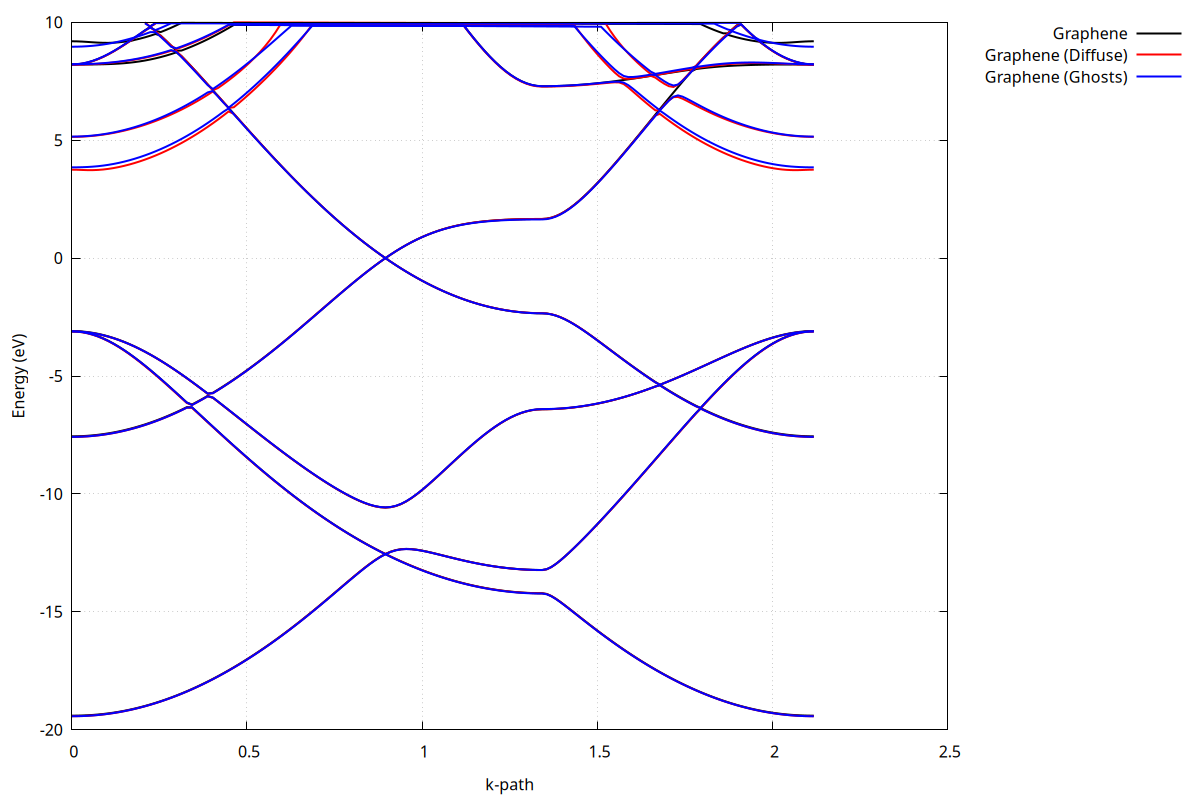

In [89]:
from IPython.display import Image
Image("bands.png")


In [91]:
%%bash
cat > bands_multiplot.gp << 'EOF'
set terminal pngcairo size 1200,800
set output "graphene_bands_compare.png"

set multiplot layout 1,3 title "Exercise 2: Graphene"

set yrange [-20:10]
set ylabel "Energy (eV)"
set grid
set xtics ("Γ" 0, "K" 1, "M" 2, "Γ" 3)
set arrow from graph 0, first 0 to graph 1, first 0 nohead dt 2 lc rgb "black"

# ---- Panel 1: DZP ----
set title "DZP"
plot "graphene.dat" using 1:2 w l lw 2 lc rgb "black" notitle

# ---- Panel 2: Diffuse ----
set title "Diffuse"
unset ylabel
plot "graphene_diffuse.dat" using 1:2 w l lw 2 lc rgb "red" notitle

# ---- Panel 3: Ghosts ----
set title "Ghosts"
plot "graphene_ghosts.dat" using 1:2 w l lw 2 lc rgb "purple" notitle

unset multiplot
EOF


In [92]:
!gnuplot bands_multiplot.gp


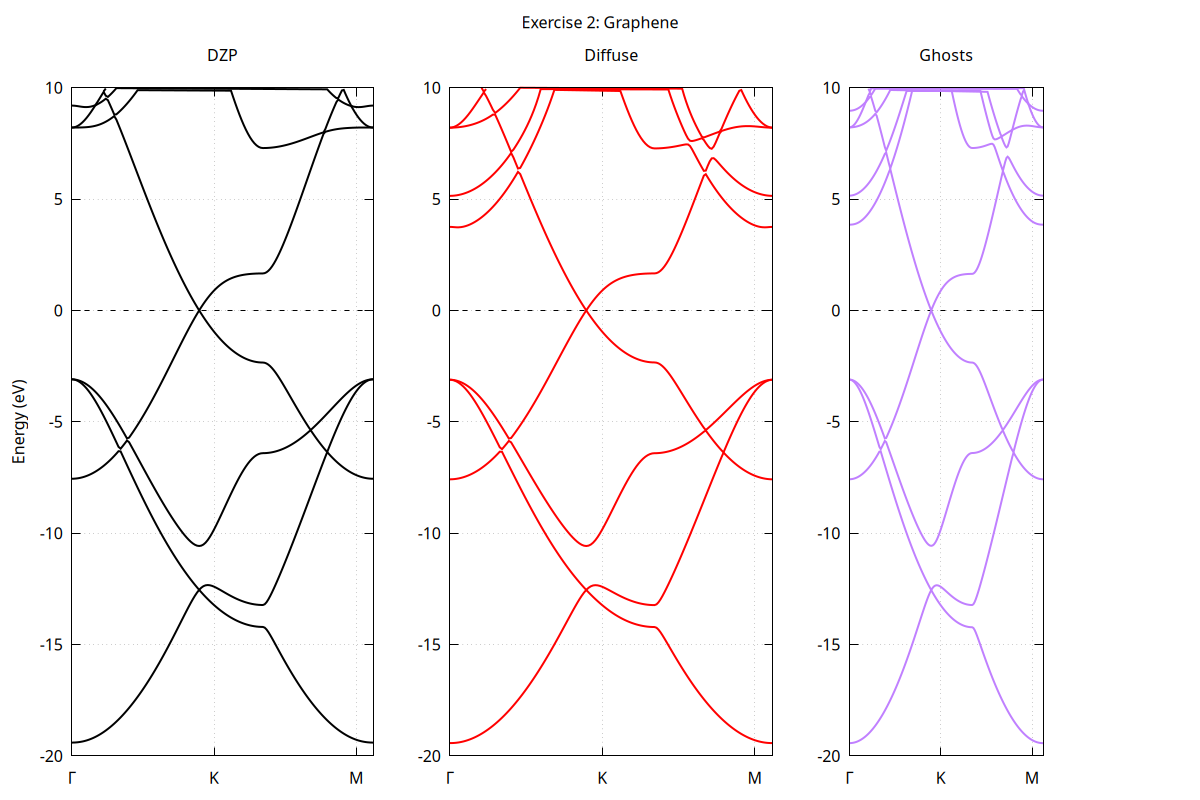

In [93]:
from IPython.display import Image
Image("graphene_bands_compare.png")
